In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import torch.optim as optim
from sklearn.model_selection import train_test_split

In [3]:
iris=load_iris()
X=iris.data
Y=iris.target

In [4]:
#normalization

Xmean=np.mean(X,axis=0)
Xstd=np.std(X,axis=0)
x_norm=(X-Xmean)/Xstd

In [5]:
x_train,x_test,y_train,y_test=train_test_split(
    x_norm,Y,test_size=0.2,random_state=42
)

In [6]:
x_train=torch.tensor(x_train,dtype=torch.float32)
x_test=torch.tensor(x_test,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.long)
y_test=torch.tensor(y_test,dtype=torch.long)

In [7]:
print(x_train.shape)
print(x_test.shape)

torch.Size([120, 4])
torch.Size([30, 4])


In [9]:
#iris Class 
class Iris(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1=nn.Linear(4,16)
        self.layer2=nn.Linear(16,3)
        self.relu=nn.ReLU()
    
    def forward(self,x):
        z1=self.layer1(x)
        a1=self.relu(z1)
        z2=self.layer2(a1)
        return z2

In [10]:
model=Iris()

In [11]:
print("\nModel architecture:")
print(model)


Model architecture:
Iris(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
  (relu): ReLU()
)


In [12]:
# Count parameters — NumPy tracked shapes manually
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 131


In [13]:
criterion=nn.CrossEntropyLoss()

In [14]:
optimizer=optim.SGD(model.parameters(),lr=0.01)

In [15]:
epochs=1000
loss_history=[]
for epoch in range(epochs):
    model.train()
    y_pred=model(x_train)
    
    loss=criterion(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if epoch%100==0:
        print(f"epoch{epoch:4d}| loss:{loss.item():.4f}")

epoch   0| loss:1.0962
epoch 100| loss:0.7468
epoch 200| loss:0.5644
epoch 300| loss:0.4620
epoch 400| loss:0.3969
epoch 500| loss:0.3513
epoch 600| loss:0.3169
epoch 700| loss:0.2894
epoch 800| loss:0.2665
epoch 900| loss:0.2469


In [16]:
model.eval()
with torch.no_grad():
    train_preds = torch.argmax(model(x_train), dim=1)
    test_preds  = torch.argmax(model(x_test),  dim=1)

train_acc = (train_preds == y_train).float().mean().item()
test_acc  = (test_preds  == y_test).float().mean().item()

print(f"\nTrain accuracy: {train_acc * 100:.1f}%")
print(f"Test  accuracy: {test_acc  * 100:.1f}%")


Train accuracy: 95.0%
Test  accuracy: 100.0%


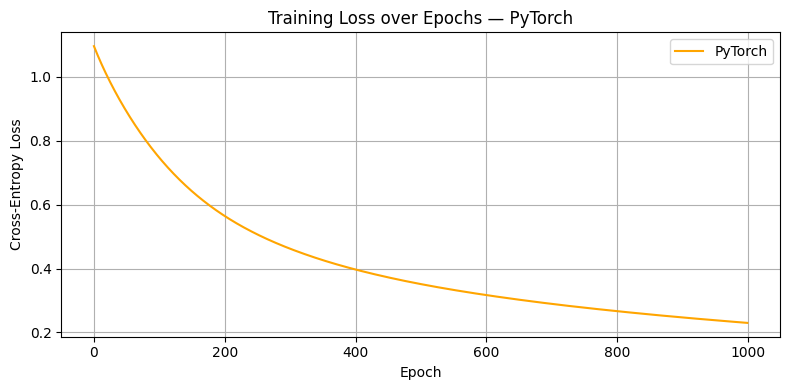

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='orange', label='PyTorch')
plt.title("Training Loss over Epochs — PyTorch")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()